# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [ ]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [ ]:
# При необходимости добавляйте новые ячейки для кода или текста

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import phik
from phik import resources, report

db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-afisha'
}

connection_string = (
    f"postgresql://{db_config['user']}:{db_config['pwd']}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['db']}"
)

engine = create_engine(connection_string)

In [27]:
query = """
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    DATE(p.created_dt_msk) AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,

    DATE(p.created_dt_msk)
    - LAG(DATE(p.created_dt_msk))
      OVER (
          PARTITION BY p.user_id
          ORDER BY p.created_dt_msk
      ) AS days_since_prev,

    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name

FROM afisha.purchases p
LEFT JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
"""

df = pd.read_sql(query, engine)
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  object        
 1   device_type_canonical  292034 non-null  object        
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  object        
 4   order_ts               292034 non-null  datetime64[ns]
 5   currency_code          292034 non-null  object        
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   days_since_prev        270034 non-null  float64       
 9   event_id               292034 non-null  int64         
 10  service_name           292034 non-null  object        
 11  event_type_main        292034 non-null  object        
 12  region_name            292034 non-null  obje

In [29]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          22000
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.describe(include = "all")

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
count,292034,292034,2.920340e+05,292034,292034,292034,292034.000000,292034.000000,270034.000000,292034.000000,292034,292034,292034,292034
unique,22000,5,NaN,153,NaN,2,NaN,NaN,NaN,NaN,36,8,81,352
top,0beb8fc0c0a9ce1,mobile,NaN,2024-10-01,NaN,rub,NaN,NaN,NaN,NaN,Билеты без проблем,концерты,Каменевский регион,Глиногорск
freq,10313,232679,NaN,7334,NaN,286961,NaN,NaN,NaN,NaN,63932,115634,91701,90087
mean,NaN,NaN,4.326435e+06,NaN,2024-09-02 12:01:25.812875008,NaN,624.833773,2.754508,3.218550,437938.109908,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000e+00,NaN,2024-06-01 00:00:42,NaN,-90.760000,1.000000,0.000000,4436.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.162567e+06,NaN,2024-07-30 11:48:37.500000,NaN,116.790000,2.000000,0.000000,361300.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.327134e+06,NaN,2024-09-12 13:04:46.500000,NaN,355.340000,3.000000,0.000000,498054.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,6.489179e+06,NaN,2024-10-09 15:36:04.249999872,NaN,809.460000,4.000000,1.000000,546269.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,8.653108e+06,NaN,2024-10-31 23:59:54,NaN,81174.540000,57.000000,148.000000,592325.000000,NaN,NaN,NaN,NaN


В результате анализа датафрейма установлено, что он содержит 292 034 записи и 13 признаков. Проверка показала отсутствие явных дубликатов. Пропущенные значения обнаружены только в столбце days_since_prev (22 000 значений), что соответствует логике данных. Для пользователей, совершивших только одну покупку, невозможно вычислить количество дней с предыдущей покупки. Остальные столбцы не содержат пропусков.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [34]:
tenge_df = pd.read_csv(
    'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [35]:
df['order_dt'] = pd.to_datetime(df['order_dt'])
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

In [36]:
df = df.merge(
    tenge_df[['data', 'curs']],
    left_on='order_dt',
    right_on='data',
    how='left'
)

In [37]:
df['revenue_rub'] = df['revenue']

In [39]:
df['revenue_rub']

0         1521.94
1          289.45
2         1258.57
3            8.49
4         1390.41
           ...   
292029     965.57
292030     965.57
292031     178.95
292032     661.53
292033     802.25
Name: revenue_rub, Length: 292034, dtype: float64

In [40]:
mask = df['currency_code'].str.lower() == 'kzt'

df.loc[mask, 'revenue_rub'] = (
    df.loc[mask, 'revenue'] * df.loc[mask, 'curs'] / 100
)

In [45]:
df[['currency_code', 'revenue', 'curs', 'revenue_rub']].head(100)

,currency_code,revenue,curs,revenue_rub
0,rub,1521.94,18.6972,1521.940000
1,rub,289.45,18.3419,289.450000
2,rub,1258.57,19.6475,1258.570000
3,rub,8.49,18.5010,8.490000
4,rub,1390.41,19.6648,1390.410000
...,...,...,...,...
95,rub,159.68,19.9266,159.680000
96,rub,239.53,19.9266,239.530000
97,rub,594.55,19.8697,594.550000
98,rub,47.56,18.4518,47.560000


In [44]:
df.head()


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name,data,curs,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск,2024-08-20,18.6972,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск,2024-07-23,18.3419,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск,2024-10-06,19.6475,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск,2024-07-13,18.5010,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк,2024-10-04,19.6648,1390.41


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [48]:
df.isna().sum() #Действительно, пропуски есть только в days_since_prev а значит всё загружено верно

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          22000
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
data                         0
curs                         0
revenue_rub                  0
dtype: int64

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  object        
 1   device_type_canonical  292034 non-null  object        
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  datetime64[ns]
 4   order_ts               292034 non-null  datetime64[ns]
 5   currency_code          292034 non-null  object        
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   days_since_prev        270034 non-null  float64       
 9   event_id               292034 non-null  int64         
 10  service_name           292034 non-null  object        
 11  event_type_main        292034 non-null  object        
 12  region_name            292034 non-null  obje

Здесь всё вроде бы впорядке и типы данных стоят верно

In [52]:
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,292034.000000,292034.000000
mean,555.106238,2.754508
std,874.381090,1.170305
min,-90.760000,1.000000
25%,113.480000,2.000000
50%,350.330000,3.000000
75%,802.050000,4.000000
max,81174.540000,57.000000


Видно что из-за преобразования теперь встречаются минусовые значения в revenue_rub, нужно будет это исправить. Также у нас слишком большое максимальное значение, ходя медианна 350. Нужно отфильтровать по 99 перцентилю как и требует задание

In [57]:
(df['revenue_rub'] < 0).sum() #381 значение ниже нуля

np.int64(381)

In [71]:
p99 = df['revenue_rub'].quantile(0.99)
p99 

np.float64(2628.4217390400004)

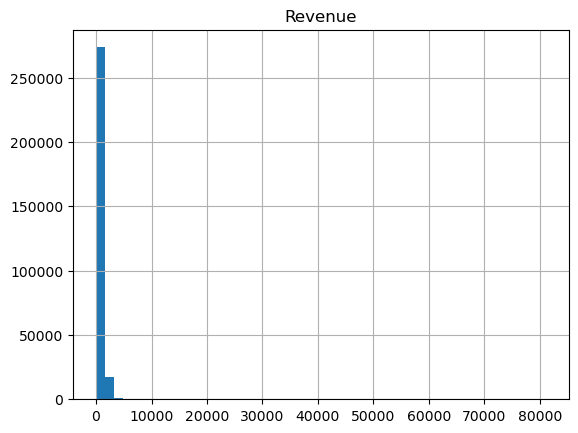

In [68]:
df['revenue_rub'].hist(bins=50)
plt.title('Revenue')
plt.show()

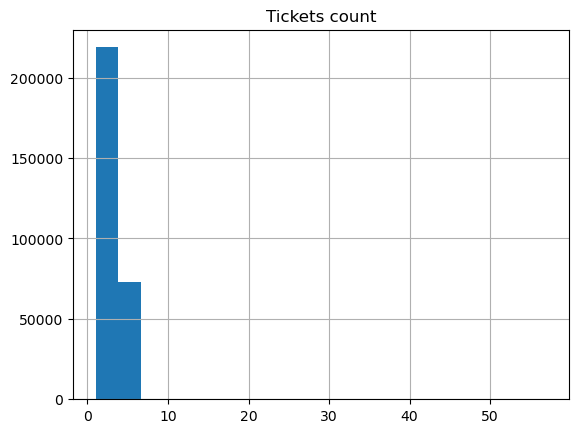

In [66]:
df['tickets_count'].hist(bins=20)
plt.title('Tickets count')
plt.show()

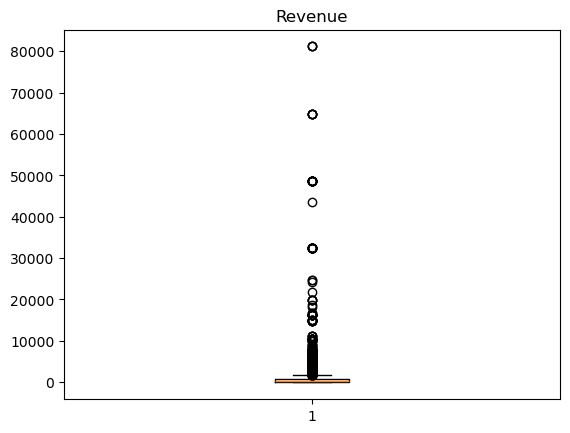

In [69]:
plt.boxplot(df['revenue_rub'])
plt.title('Revenue')
plt.show()

Такой график намного лучше показывает картину

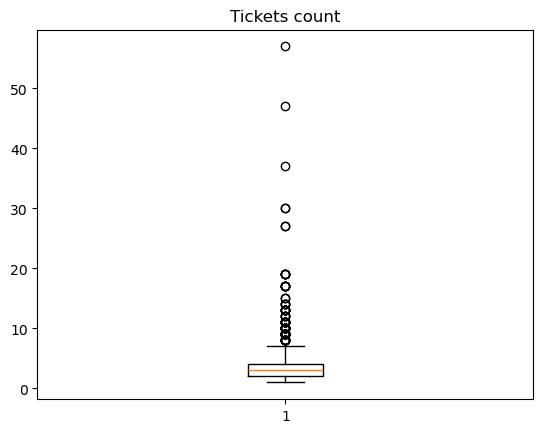

In [70]:
plt.boxplot(df['tickets_count'])
plt.title('Tickets count')
plt.show()

Был создан новый столбец revenue_rub который переводит всё к единной валюте. Однако в ходе предобработки данных, обнаружились выбросы, где максимальное значение достигло 81174, при медианне 350. Из-за этого пришлось переводить всё к 99 перцентилю. Пропуски обнаружены только в столбце days_since_prev, что в целом - норма,для пользователей с единственной покупкой невозможно вычислить количество дней с предыдущего заказа. Типы данных соответствуют содержимому столбцов: даты представлены в формате datetime, числовые показатели - в форматах int64 и float64, категориальные признаки в формате object.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [72]:
df = df.sort_values(by=['user_id', 'order_ts'])

In [73]:
user_profile = df.groupby('user_id').agg(
    first_order=('order_ts', 'min'),
    last_order=('order_ts', 'max'),
    orders_count=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).reset_index()

user_profile.head()


,user_id,first_order,last_order,orders_count,avg_revenue,avg_tickets,avg_days_between
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.0
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.0
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.0


In [74]:
first_orders = (df.groupby('user_id').first()[[
          'device_type_canonical',
          'region_name',
          'service_name',
          'event_type_main'
      ]]
      .reset_index()
)

first_orders.head()

,user_id,device_type_canonical,region_name,service_name,event_type_main
0,0002849b70a3ce2,mobile,Каменевский регион,Край билетов,театр
1,0005ca5e93f2cf4,mobile,Каменевский регион,Мой билет,выставки
2,000898990054619,mobile,Североярская область,Лови билет!,другое
3,00096d1f542ab2b,desktop,Каменевский регион,Край билетов,театр
4,000a55a418c128c,mobile,Поленовский край,Лучшие билеты,театр


In [76]:
user_profile = user_profile.merge(first_orders,on = 'user_id')

In [78]:
user_profile.head()

,user_id,first_order,last_order,orders_count,avg_revenue,avg_tickets,avg_days_between,device_type_canonical,region_name,service_name,event_type_main
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр


In [79]:
user_profile['is_two'] = (user_profile['orders_count'] >= 2)

In [80]:
user_profile['is_five'] = (user_profile['orders_count'] >= 5)

In [81]:
user_profile.head()

,user_id,first_order,last_order,orders_count,avg_revenue,avg_tickets,avg_days_between,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,True,False
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,True,False


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [84]:
user_profile['user_id'].nunique() #общее число пользователей

22000

In [86]:
user_profile['avg_revenue'].mean() #средняя выручка с одного заказа

np.float64(572.9187137250108)

In [87]:
user_profile['is_two'].mean() #доля пользоватаелей совершивших 2 и более заказа

np.float64(0.6187272727272727)

In [89]:
user_profile['is_five'].mean() #доля пользователей совершивших 5 и более

np.float64(0.2917272727272727)

In [90]:
user_profile['orders_count'].describe() # колво заказов

count    22000.000000
mean        13.274273
std        122.931213
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10313.000000
Name: orders_count, dtype: float64

In [91]:
user_profile['avg_tickets'].describe() #колво ср.билетов

count    22000.000000
mean         2.755687
std          0.920232
min          1.000000
25%          2.000000
50%          2.764706
75%          3.125000
max         12.000000
Name: avg_tickets, dtype: float64

In [92]:
user_profile['avg_days_between'].describe() #

count    13612.000000
mean        15.815879
std         22.268425
min          0.000000
25%          1.000000
50%          8.000000
75%         20.333333
max        148.000000
Name: avg_days_between, dtype: float64

In [97]:
user_profile[user_profile['orders_count'] == user_profile['orders_count'].max()]

,user_id,first_order,last_order,orders_count,avg_revenue,avg_tickets,avg_days_between,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
988,0beb8fc0c0a9ce1,2024-06-01 00:18:28,2024-10-31 23:28:28,10313,522.362163,2.874333,0.01474,mobile,Североярская область,Билеты в руки,концерты,True,True


Возможно это какой-то тестовый аккаунт или произошел какой-то сбой в данных

In [112]:
user_profile[user_profile['orders_count'] > 1000].count()

user_id                  31
first_order              31
last_order               31
orders_count             31
avg_revenue              31
avg_tickets              31
avg_days_between         31
device_type_canonical    31
region_name              31
service_name             31
event_type_main          31
is_two                   31
is_five                  31
dtype: int64

Пользователей с общим количеством заказов больше тысячи - 31

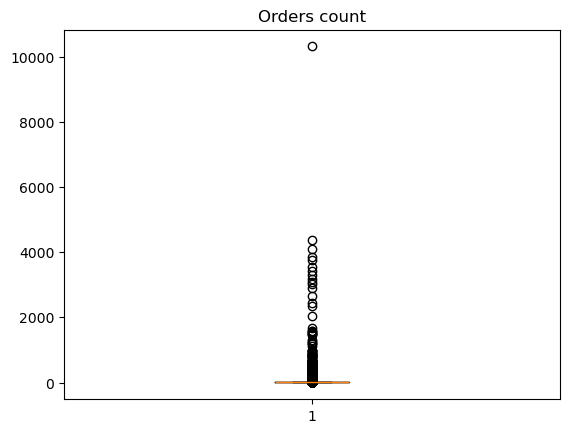

In [93]:
plt.boxplot(user_profile['orders_count'])
plt.title('Orders count')
plt.show()

Можно заметить что есть аномалии, особенно сильно выделяется отметка в 10.000

In [106]:
p999 = user_profile['orders_count'].quantile(0.99)
print(p999) 

152.0099999999984


На фоне того, что 99% пользователей укладываются в 152 заказа, такие значения являются явными выбросами

In [108]:
user_profile_filtered = user_profile[
    user_profile['orders_count'] <= p999
]

after = len(user_profile_filtered)
after

21780

In [109]:
user_profile_filtered['orders_count'].describe() 

count    21780.000000
mean         6.526997
std         14.352235
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: orders_count, dtype: float64

Такие значения больше подходят на правду

Анализ распределения количества заказов показал наличие аномально активных пользователей. Несмотря на то что 99% пользователей совершили не более 152 заказов, в выборке присутствуют пользователи с количеством заказов до 10 313. Такие значения существенно отличаются от основной массы наблюдений. В связи с этим для дальнейшего анализа были исключены пользователи, количество заказов которых превышает 99-й перцентиль (152 заказа).

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [123]:
event_dist = (
    user_profile.groupby('event_type_main')
    .agg(users=('user_id', 'count'))
    .reset_index()
)

event_dist['share'] = (
    event_dist['users'] /
    event_dist['users'].sum() * 100
)

event_dist = event_dist.sort_values('users', ascending=False)

event_dist

,event_type_main,users,share
2,концерты,9716,44.163636
1,другое,5495,24.977273
5,театр,4333,19.695455
4,стендап,1115,5.068182
3,спорт,808,3.672727
0,выставки,414,1.881818
7,ёлки,93,0.422727
6,фильм,26,0.118182


In [116]:
device_dist = (
    user_profile.groupby('device_type_canonical')
    .agg(users=('user_id', 'count'))
    .reset_index()
)

device_dist['share'] = (
    device_dist['users'] /
    device_dist['users'].sum() * 100
)

device_dist = device_dist.sort_values('users', ascending=False)

device_dist

,device_type_canonical,users,share
1,mobile,18136,82.436364
0,desktop,3764,17.109091
3,tablet,99,0.450000
2,other,1,0.004545


In [117]:
region_dist = (
    user_profile.groupby('region_name')
    .agg(users=('user_id', 'count'))
    .reset_index()
)

region_dist['share'] = (
    region_dist['users'] /
    region_dist['users'].sum() * 100
)

region_dist = region_dist.sort_values('users', ascending=False)

region_dist

,region_name,users,share
23,Каменевский регион,7228,32.854545
60,Североярская область,3810,17.318182
77,Широковская область,1245,5.659091
45,Озернинский край,681,3.095455
41,Малиновоярский округ,537,2.440909
...,...,...,...
56,Светолесский край,2,0.009091
17,Залесский край,2,0.009091
5,Верхозёрский край,1,0.004545
66,Сосноводолинская область,1,0.004545


In [121]:
service_dist = (
    user_profile.groupby('service_name')
    .agg(users=('user_id', 'count'))
    .reset_index()
)

service_dist['share'] = (
    service_dist['users'] /
    service_dist['users'].sum() * 100
)

service_dist = service_dist.sort_values('users', ascending=False)

service_dist.head()

,service_name,users,share
3,Билеты без проблем,5256,23.890909
22,Мой билет,3026,13.754545
19,Лови билет!,2862,13.009091
4,Билеты в руки,2595,11.795455
23,Облачко,2198,9.990909


Наиболее популярным типом первого мероприятия являются концерты - 44%, а основной канал покупки - мобильные устройства, составляют 82 процента. Пользователи сосредоточены в небольшом числе регионов, тогда как многие регионы представлены единичными наблюдениями. Среди билетных операторов лидирует сервис «Билеты без проблем» 23.9%, однако существенная доля пользователей распределена между несколькими крупными операторами. Полученные результаты свидетельствуют о наличии выраженных точек входа пользователей на платформу, которые можно использовать при дальнейшем исследовании факторов, влияющих на возврат пользователей.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [132]:
event_return = (
    user_profile.groupby('event_type_main')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

event_return['return_rate'] *= 100
event_return = event_return.sort_values('return_rate', ascending=False)

event_return

,event_type_main,users,return_rate
6,фильм,26,80.769231
0,выставки,414,64.009662
5,театр,4333,63.974152
2,концерты,9716,62.453685
4,стендап,1115,61.255605
1,другое,5495,60.000000
3,спорт,808,56.311881
7,ёлки,93,54.838710


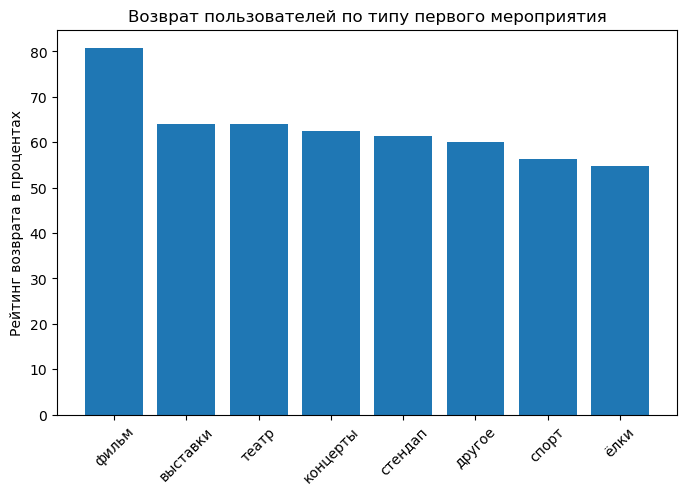

In [133]:
plt.figure(figsize=(8,5))

plt.bar(
    event_return['event_type_main'],
    event_return['return_rate']
)

plt.xticks(rotation=45)
plt.ylabel('Рейтинг возврата в процентах')
plt.title('Возврат пользователей по типу первого мероприятия')
plt.show()

In [134]:
device_return = (
    user_profile.groupby('device_type_canonical')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

device_return['return_rate'] *= 100
device_return = device_return.sort_values('return_rate', ascending=False)

device_return

,device_type_canonical,users,return_rate
0,desktop,3764,64.319872
1,mobile,18136,61.408249
3,tablet,99,54.545455
2,other,1,0.000000


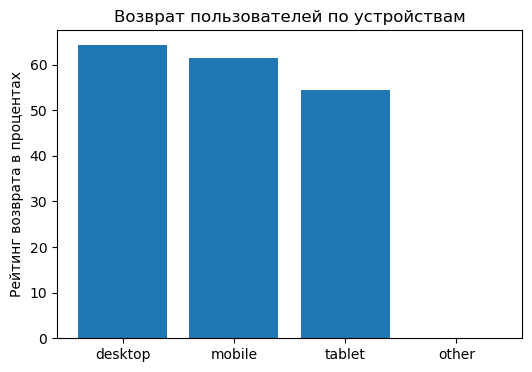

In [135]:
plt.figure(figsize=(6,4))

plt.bar(
    device_return['device_type_canonical'],
    device_return['return_rate']
)

plt.ylabel('Рейтинг возврата в процентах')
plt.title('Возврат пользователей по устройствам')
plt.show()

In [136]:
region_return = (
    user_profile.groupby('region_name')
    .agg(
        users=('user_id','count'),
        return_rate=('is_two','mean')
    )
    .reset_index()
)

region_return['return_rate'] *= 100

top10_regions = (
    region_return
    .sort_values('users', ascending=False)
    .head(10)
)

top10_regions

,region_name,users,return_rate
23,Каменевский регион,7228,62.949640
60,Североярская область,3810,64.304462
77,Широковская область,1245,65.220884
45,Озернинский край,681,54.919236
41,Малиновоярский округ,537,56.983240
76,Шанырский регион,509,68.565815
74,Травяная область,499,61.923848
57,Светополянский округ,471,66.454352
52,Речиновская область,445,63.146067
78,Яблоневская область,419,59.904535


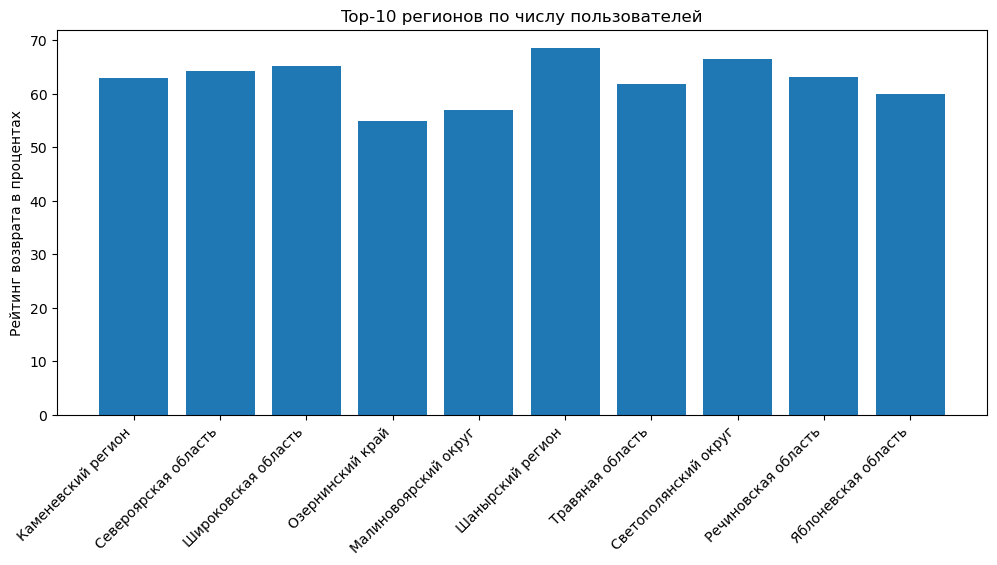

In [137]:
plt.figure(figsize=(12,5))

plt.bar(
    top10_regions['region_name'],
    top10_regions['return_rate']
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Рейтинг возврата в процентах')
plt.title('Top-10 регионов по числу пользователей')
plt.show()

In [138]:
service_return = (
    user_profile.groupby('service_name')
    .agg(
        users=('user_id','count'),
        return_rate=('is_two','mean')
    )
    .reset_index()
)

service_return['return_rate'] *= 100

top10_services = (
    service_return
    .sort_values('users', ascending=False)
    .head(10)
)

top10_services

,service_name,users,return_rate
3,Билеты без проблем,5256,60.863775
22,Мой билет,3026,61.500330
19,Лови билет!,2862,61.670161
4,Билеты в руки,2595,63.198459
23,Облачко,2198,61.874431
7,Весь в билетах,1321,63.512491
20,Лучшие билеты,1201,61.365529
24,Прачечная,591,63.451777
17,Край билетов,463,65.658747
12,Дом культуры,354,64.971751


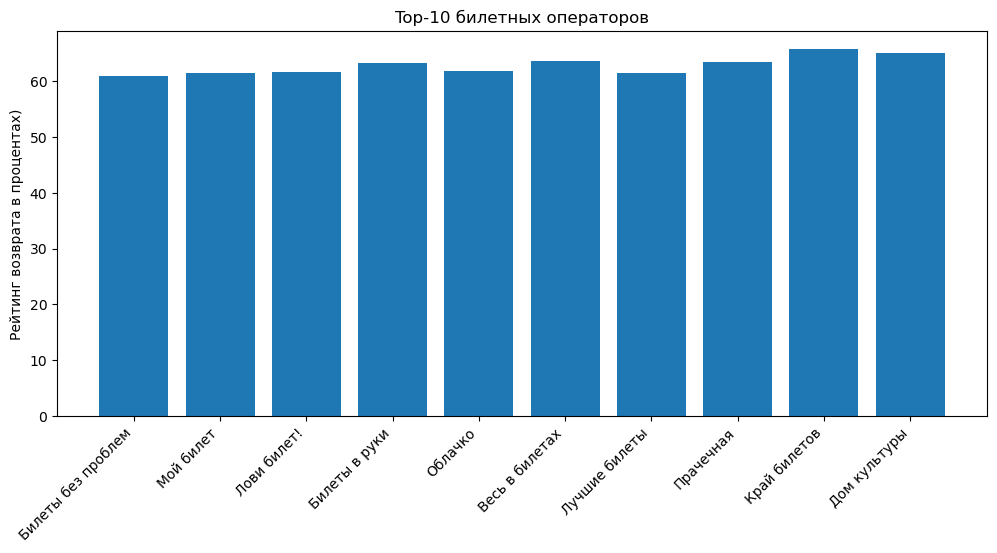

In [139]:
plt.figure(figsize=(12,5))

plt.bar(
    top10_services['service_name'],
    top10_services['return_rate']
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Рейтинг возврата в процентах)')
plt.title('Top-10 билетных операторов')
plt.show()

# Промежуточный вывод (ответы на вопросы)
Средняя доля пользователей, совершивших повторную покупку, составляет 61,87%. Сегменты, у которых показатель выше этого значения, возвращаются чаще среднего.
По типу первого мероприятия
Театр - 63,97%.
Концерты - 62,45%.
Выставки - 64,01%, однако этот сегмент значительно меньше по размеру (414 пользователей).
Категорию Фильм (80,77%) нельзя считать надежной, поскольку в ней всего 26 пользователей.
Пользователи, совершившие первую покупку с desktop, возвращаются чаще (64,32%) по сравнению с пользователями mobile (61,41%).

Среди крупнейших регионов наиболее высокую долю повторных заказов показывают:

Шаныркский регион - 68,57%
Светополянский округ - 66,45%
Широковская область - 65,22%

Наиболее высокую долю возвратов среди операторов демонстрируют:

Край билетов - 65,66%
Дом культуры - 64,97%
Прачечная - 63,45%


# Наблюдаются ли успешные «точки входа»?
## Да, наблюдаются

Можно выделить несколько таких сегментов
пользователи, впервые купившие билет в театр
пользователи, совершившие первый заказ с настольного компьютера (desktop)
жители ряда регионов (например, Шаныркский регион и Светополянский округ)
клиенты некоторых билетных операторов, прежде всего «Край билетов», «Дом культуры» и «Весь в билетах»

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [140]:
user_profile.groupby('event_type_main')['is_two'].mean() * 100

event_type_main
выставки    64.009662
другое      60.000000
концерты    62.453685
спорт       56.311881
стендап     61.255605
театр       63.974152
фильм       80.769231
ёлки        54.838710
Name: is_two, dtype: float64

Пользователи, впервые купившие билет на спортивное мероприятие, возвращаются реже, чем пользователи, впервые посетившие концерт

In [142]:
top10_regions

,region_name,users,return_rate
23,Каменевский регион,7228,62.949640
60,Североярская область,3810,64.304462
77,Широковская область,1245,65.220884
45,Озернинский край,681,54.919236
41,Малиновоярский округ,537,56.983240
76,Шанырский регион,509,68.565815
74,Травяная область,499,61.923848
57,Светополянский округ,471,66.454352
52,Речиновская область,445,63.146067
78,Яблоневская область,419,59.904535


In [143]:
top10_regions['return_rate'] = top10_regions['return_rate'] / 100

top10_regions[['users', 'return_rate']].corr()

,users,return_rate
users,1.000000,0.121169
return_rate,0.121169,1.000000


In [145]:
region_stats = (
    user_profile.groupby('region_name')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)


In [146]:
region_stats['users'].corr(region_stats['return_rate'])

np.float64(0.11617549611691776)

Коэффициент корреляции составил 0.116, что свидетельствует об очень слабой положительной связи. Следовательно, нельзя утверждать, что в регионах с большим количеством пользователей доля повторных заказов выше

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


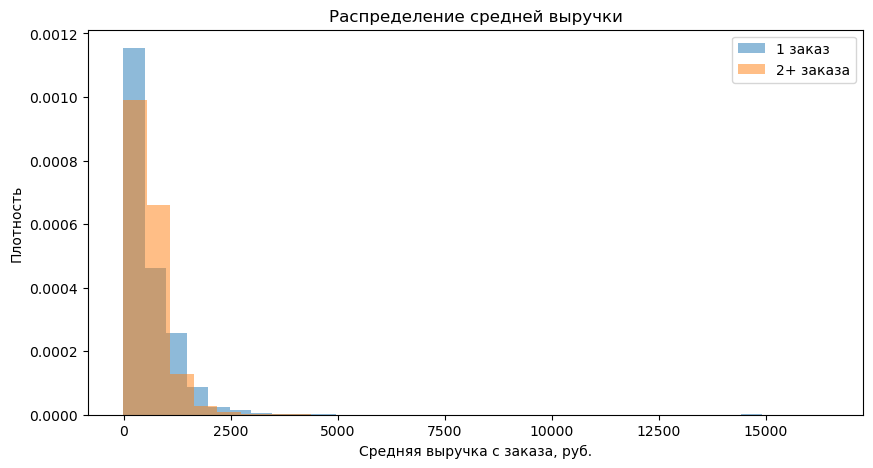

In [150]:
one_order = user_profile[user_profile['is_two'] == False]
repeat = user_profile[user_profile['is_two'] == True]

plt.figure(figsize=(10, 5))

plt.hist(
    one_order['avg_revenue'],
    bins=30,
    alpha=0.5,
    density=True,
    label='1 заказ'
)
plt.hist(
    repeat['avg_revenue'],
    bins=30,
    alpha=0.5,
    density=True,
    label='2+ заказа'
)
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки')
plt.legend()
plt.show()

In [151]:
user_profile.groupby('is_two')['avg_revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
is_two,,,,,,,,
False,8388.0,565.596623,630.001336,-10.770,131.772500,378.870000,836.912500,14913.530000
True,13612.0,577.430740,495.094497,-5.385,277.380417,508.118036,763.370625,16453.923333


По графику видно, что распределения у обеих групп очень похожи. Большинство пользователей, независимо от того, вернулись они на сервис или нет, совершают заказы со средней стоимостью примерно до 1000-1500 рублей.

При этом пользователи, которые сделали 2 и более заказа, в среднем тратят немного больше. Это видно и по статистике: медианная средняя выручка у них составляет около 508 руб., тогда как у пользователей с одним заказом — около 379 руб. Также у них выше среднее значение (577 руб. против 566 руб.).

Разница между группами есть, но она не слишком большая.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [153]:
group_2_4 = user_profile[
    (user_profile['orders_count'] >= 2) &
    (user_profile['orders_count'] <= 4)
]['avg_revenue']

In [158]:
group_2_4

1         774.010000
2         767.213333
4          61.310000
6         352.945000
9         326.623333
            ...     
21991    1065.175000
21992     548.740000
21993     818.710000
21994      50.515000
21996     850.995000
Name: avg_revenue, Length: 7194, dtype: float64

In [159]:
is_five = user_profile[
    user_profile['orders_count'] >= 5]['avg_revenue']


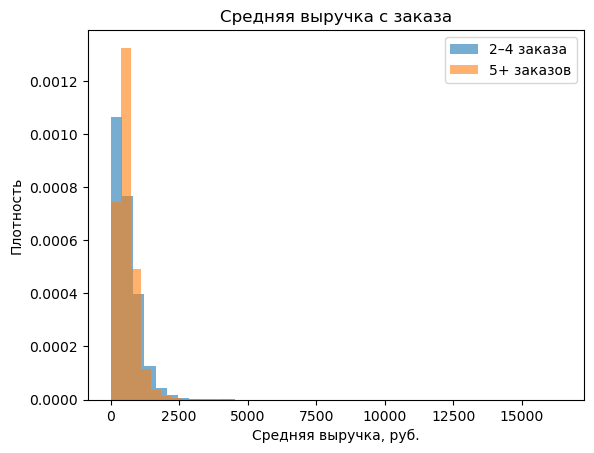

In [160]:
plt.hist(group_2_4,
         bins=40,
         alpha=0.6,
         density=True,
         label='2–4 заказа')

plt.hist(is_five,
         bins=40,
         alpha=0.6,
         density=True,
         label='5+ заказов')

plt.title('Средняя выручка с заказа')
plt.xlabel('Средняя выручка, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

Пользователи, совершившие 2–4 заказа и 5 и более заказов, имеют очень похожее распределение средней выручки с заказа. Основная часть пользователей в обеих группах тратит примерно до 1000–2000 рублей за заказ. 

# Ответ на вопрос 
Разница есть, но она незначительная. Можно сделать вывод, что большое количество заказов не обязательно связано с высокой средней стоимостью одного заказа. Скорее, пользователи возвращаются чаще из-за регулярности покупок, а не из-за того, что совершают более дорогие заказы.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

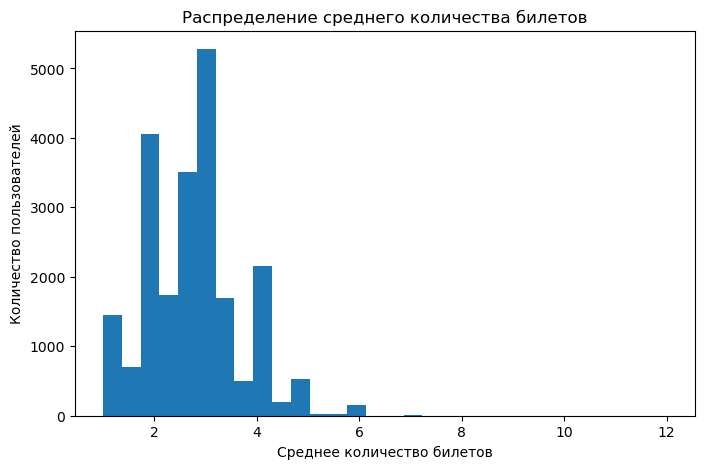

In [161]:
plt.figure(figsize=(8, 5))
plt.hist(user_profile['avg_tickets'], bins=30)
plt.title('Распределение среднего количества билетов')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.show()

In [162]:
user_profile['tickets_group'] = pd.cut(
    user_profile['avg_tickets'],
    bins=[1, 2, 3, 5, float('inf')],
    labels=[
        '1–2 билета',
        '2–3 билета',
        '3–5 билетов',
        '5+ билетов'
    ],
    include_lowest=True
)

In [163]:
user_profile.head()

,user_id,first_order,last_order,orders_count,avg_revenue,avg_tickets,avg_days_between,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,tickets_group
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False,3–5 билетов
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,True,False,2–3 билета
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False,2–3 билета
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False,3–5 билетов
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,True,False,1–2 билета


In [164]:
tickets_stats = (
    user_profile
    .groupby('tickets_group')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_stats['return_rate'] *= 100

tickets_stats

C:\Users\mewli\AppData\Local\Temp\ipykernel_2960\2081007128.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('tickets_group')


,tickets_group,users,return_rate
0,1–2 билета,6135,40.114099
1,2–3 билета,10134,74.758240
2,3–5 билетов,5522,63.491489
3,5+ билетов,209,33.014354


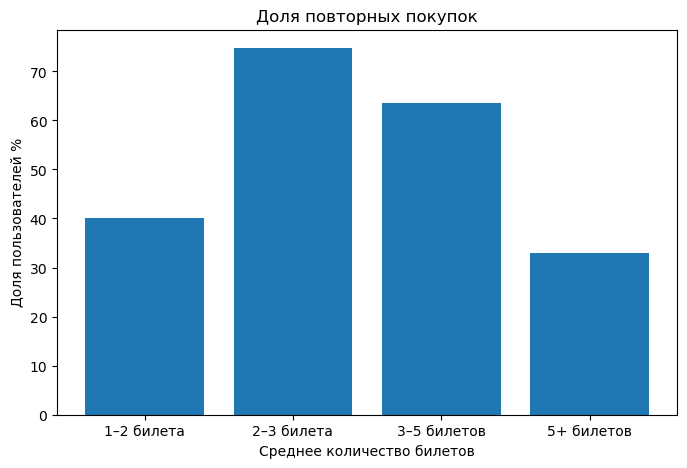

In [166]:
plt.figure(figsize=(8,5))
plt.bar(
    tickets_stats['tickets_group'].astype(str),
    tickets_stats['return_rate']
)

plt.title('Доля повторных покупок')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Доля пользователей %')
plt.show()

Пользователи распределены неравномерно. Основная часть пользователей сосредоточена в двух сегментах:
2–3 билета - 10 134 пользователя
1–2 билета - 6 135 пользователей
3–5 билетов - 5 522 пользователя


Самая высокая доля повторных покупок наблюдается у пользователей, которые в среднем приобретают 2–3 билета - 74,8%.
Пользователи, покупающие 3–5 билетов, также довольно часто возвращаются 63,5%
У сегмента 1–2 билета доля повторных покупок значительно ниже около 40,1%.
Самый низкий показатель у пользователей, покупающих 5 и более билетов всего 33 процента, однако стоит учитывает что для этой категории выявлено всего 209 человек

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [168]:
user_profile['weekday'] = user_profile['first_order'].dt.day_name()

In [169]:
user_profile.head()

,user_id,first_order,last_order,orders_count,avg_revenue,avg_tickets,avg_days_between,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,tickets_group,weekday
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False,3–5 билетов,Tuesday
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,True,False,2–3 билета,Tuesday
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False,2–3 билета,Saturday
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False,3–5 билетов,Thursday
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,True,False,1–2 билета,Sunday


In [170]:
weekday_stats = (
    user_profile
    .groupby('weekday')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

weekday_stats['return_rate'] *= 100

weekday_stats

,weekday,users,return_rate
0,Friday,3276,60.073260
1,Monday,2958,63.421231
2,Saturday,3473,64.238411
3,Sunday,2833,60.430639
4,Thursday,3134,59.572431
5,Tuesday,3230,62.569659
6,Wednesday,3096,62.564599


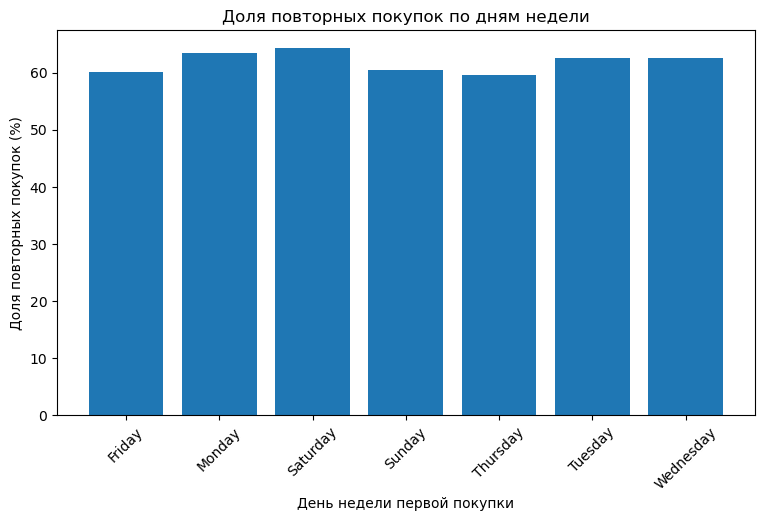

In [171]:
plt.figure(figsize=(9,5))

plt.bar(
    weekday_stats['weekday'],
    weekday_stats['return_rate']
)

plt.title('Доля повторных покупок по дням недели')
plt.xlabel('День недели первой покупки')
plt.ylabel('Доля повторных покупок (%)')

plt.xticks(rotation=45)
plt.show()

День недели влияет не сильно

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [174]:
gr2_4 = user_profile[
    user_profile['orders_count'].between(2, 4)
]

gr_5 = user_profile[
    user_profile['orders_count'] >= 5
]

In [177]:
gr2_4['avg_days_between'].describe()

count    7194.000000
mean       21.320313
std        28.605477
min         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
max       148.000000
Name: avg_days_between, dtype: float64

In [178]:
gr_5['avg_days_between'].describe()

count    6418.000000
mean        9.645903
std         7.908298
min         0.000000
25%         3.432432
50%         7.833333
75%        13.888889
max        37.500000
Name: avg_days_between, dtype: float64

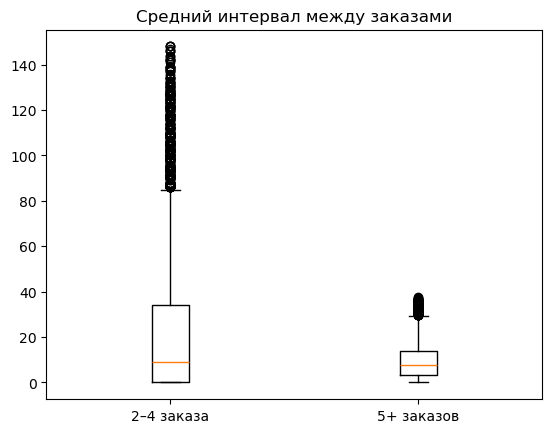

In [181]:
plt.boxplot([
    gr2_4['avg_days_between'].dropna(),
    gr_5['avg_days_between'].dropna()
])

plt.xticks([1, 2], ['2–4 заказа', '5+ заказов'])
plt.title('Средний интервал между заказами')

plt.show()

По графику видно, что пользователи, совершившие 5 и более заказов, покупают билеты чаще, чем пользователи с 2–4 заказами. У них медианный интервал между заказами меньше. Это говорит о том, что такие пользователи возвращаются на сервис более регулярно. У них более стабильное поведение, т.к интервал более узкий чем у 2-4 заказа

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [183]:
user_profile.columns

Index(['user_id', 'first_order', 'last_order', 'orders_count', 'avg_revenue',
       'avg_tickets', 'avg_days_between', 'device_type_canonical',
       'region_name', 'service_name', 'event_type_main', 'is_two', 'is_five',
       'tickets_group', 'weekday'],
      dtype='object')

In [186]:
corr_df = user_profile.drop(columns=[
    'user_id',
    'first_order',
    'last_order',
    'is_two',
    'is_five'
])

In [187]:
phik_matrix = corr_df.phik_matrix(
    interval_cols=[
        'orders_count',
        'avg_revenue',
        'avg_tickets',
        'avg_days_between'
    ]
)

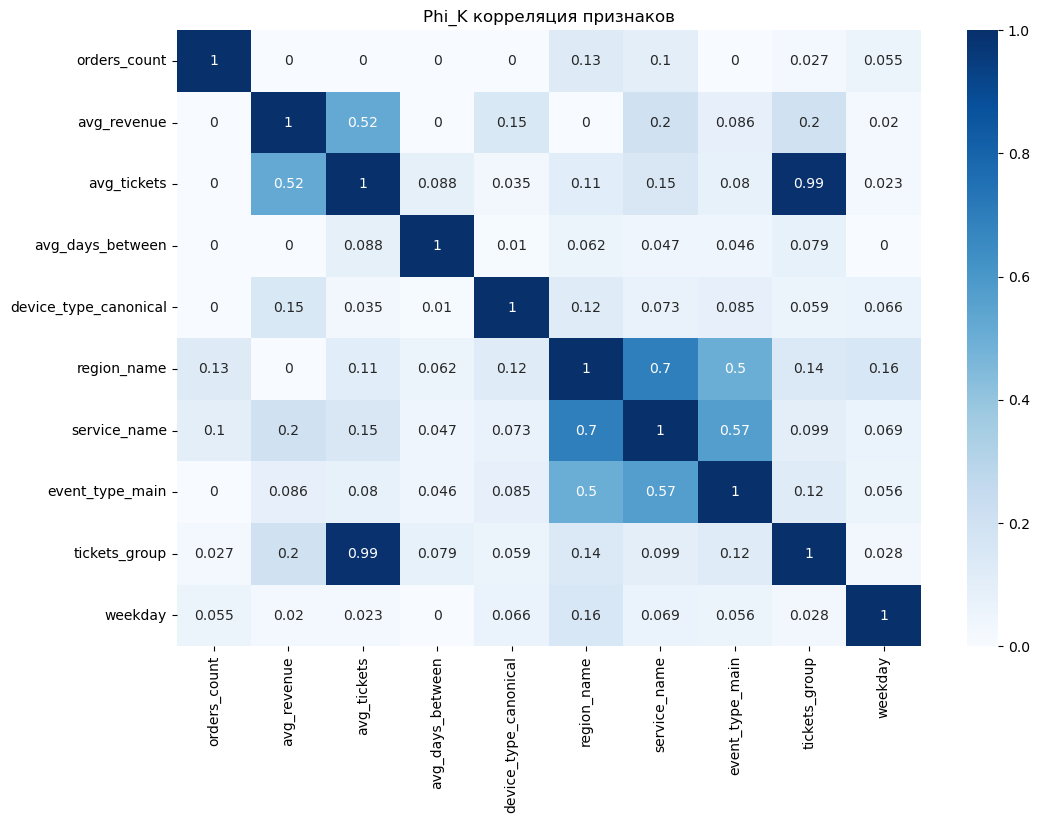

In [189]:
import seaborn as sns
plt.figure(figsize=(12, 8))

sns.heatmap(
    phik_matrix,
    annot=True,
    cmap='Blues'
)

plt.title('Phi_K корреляция признаков')
plt.show()

In [190]:
phik_matrix['orders_count'].sort_values(ascending=False)

orders_count             1.000000
region_name              0.126826
service_name             0.101796
weekday                  0.055451
tickets_group            0.027111
avg_revenue              0.000000
avg_tickets              0.000000
avg_days_between         0.000000
device_type_canonical    0.000000
event_type_main          0.000000
Name: orders_count, dtype: float64

In [191]:
one_order = user_profile[user_profile['orders_count'] == 1]

In [192]:
two_four = user_profile[
    (user_profile['orders_count'] >= 2) &
    (user_profile['orders_count'] <= 4)
]

In [193]:
five_plus = user_profile[
    user_profile['orders_count'] >= 5
]

In [197]:
phik_one_order = one_order.drop(columns=['user_id', 'first_order','last_order','is_two','is_five']).phik_matrix(interval_cols=[
        'orders_count',
        'avg_revenue',
        'avg_tickets',
        'avg_days_between'
    ]
)

D:\AnacondaNavigator\Lib\site-packages\phik\data_quality.py:72: UserWarning: Not enough unique value for variable orders_count for analysis 1. Dropping this column
  warnings.warn(
D:\AnacondaNavigator\Lib\site-packages\phik\data_quality.py:72: UserWarning: Not enough unique value for variable avg_days_between for analysis 0. Dropping this column
  warnings.warn(


In [200]:
phik_two_four_order = two_four.drop(columns=['user_id', 'first_order','last_order','is_two','is_five']).phik_matrix(interval_cols=[
        'orders_count',
        'avg_revenue',
        'avg_tickets',
        'avg_days_between'
    ]
)

In [201]:
phik_five_plus_order = five_plus.drop(columns=['user_id', 'first_order','last_order','is_two','is_five']).phik_matrix(interval_cols=[
        'orders_count',
        'avg_revenue',
        'avg_tickets',
        'avg_days_between'
    ]
)

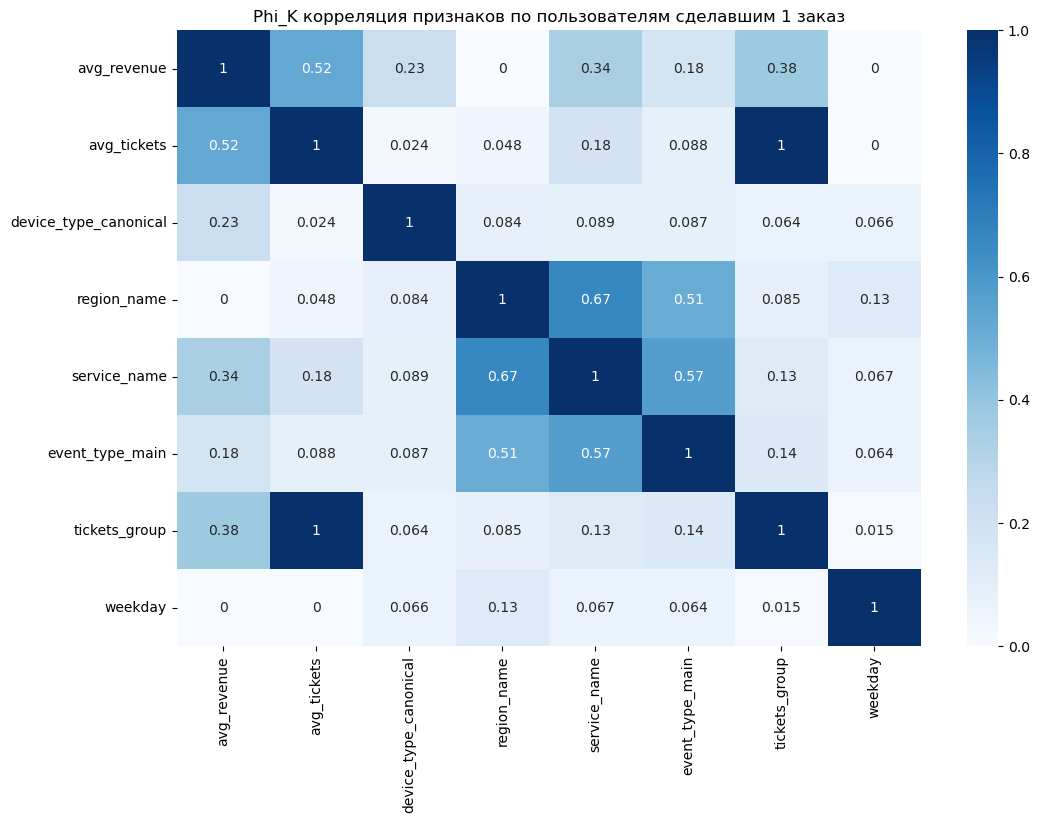

In [202]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    phik_one_order,
    annot=True,
    cmap='Blues'
)

plt.title('Phi_K корреляция признаков по пользователям сделавшим 1 заказ')
plt.show()

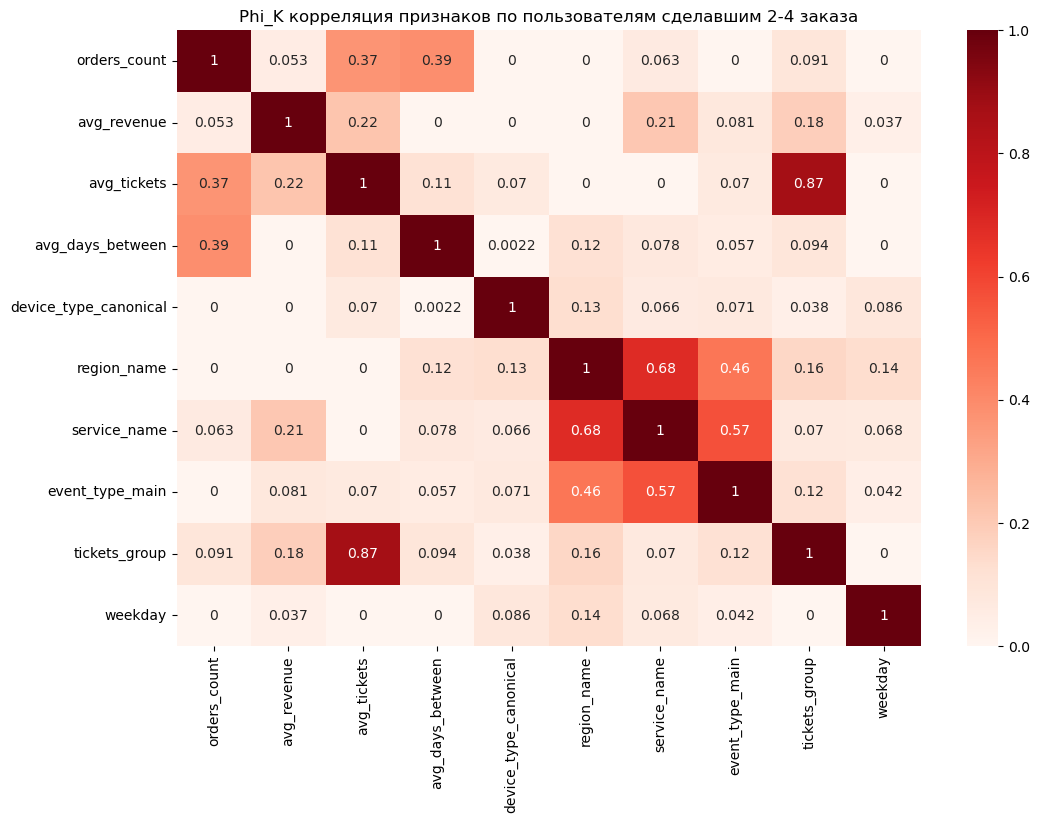

In [208]:
import seaborn as sns
plt.figure(figsize=(12, 8))

sns.heatmap(
    phik_two_four_order,
    annot=True,
    cmap='Reds'
)

plt.title('Phi_K корреляция признаков по пользователям сделавшим 2-4 заказа')
plt.show()

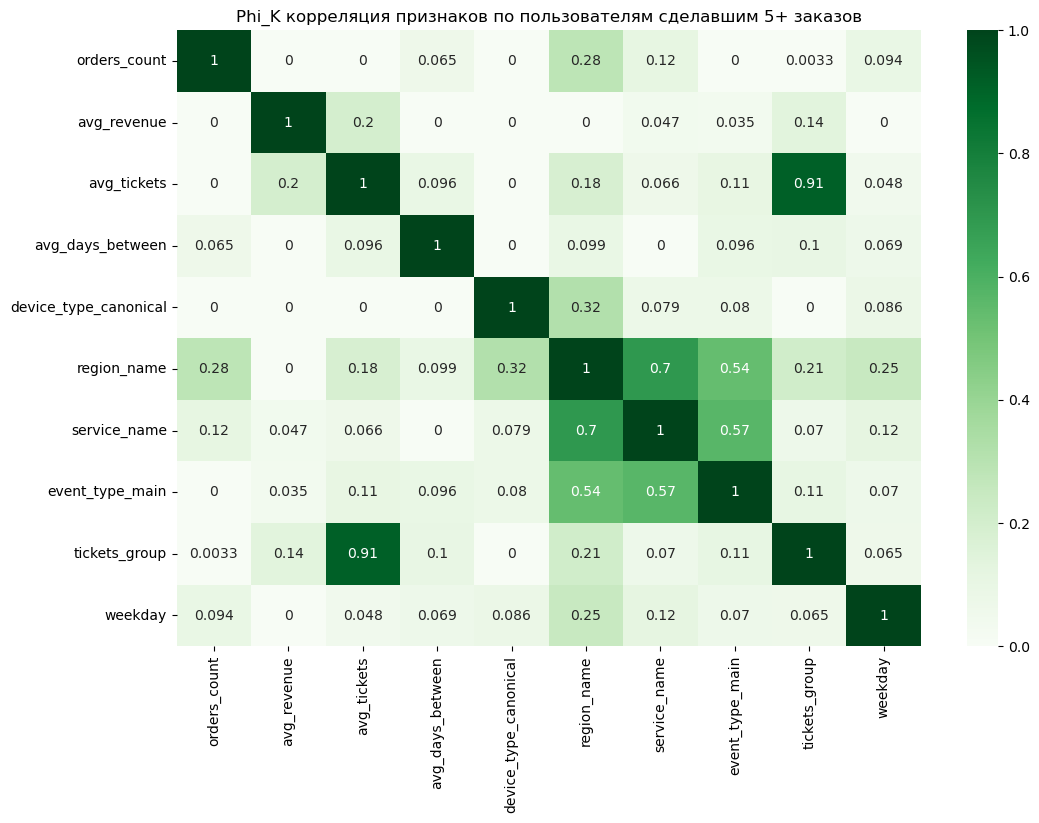

In [207]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    phik_five_plus_order,
    annot=True,
    cmap='Greens'
)

plt.title('Phi_K корреляция признаков по пользователям сделавшим 5+ заказов')
plt.show()

По результатам корреляционного анализа сильной зависимости между количеством заказов и отдельными признаками профиля пользователя обнаружить не удалось. Наиболее заметную связь показывают среднее количество билетов в заказе и средний интервал между покупками, однако эта связь наблюдается в основном у пользователей, совершивших 2-4 заказа. Для наиболее активных пользователей (5+ заказов) влияние этих признаков становится значительно слабее.

Также видно, что такие признаки, как тип устройства и день недели первой покупки, практически не связаны с количеством заказов. На тепловых картах заметны сильные зависимости между некоторыми категориальными признаками (например, регионом и билетным оператором), однако они отражают особенности структуры данных и не объясняют активность пользователей.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

В ходе анализа были проанализированы данные о пользователях Яндекс Афиши и их заказах. Перед анализом данные были подготовлены: обработаны выбросы, рассчитаны дополнительные показатели а также сформированы признаки описывающие первый заказ пользователя.

Большинство пользователей совершают всего один или несколько заказов. При этом основная аудитория приходит на платформу за билетами на концерты, а чаще всего первая покупка совершается с мобильного устройства. По регионам и билетным операторам пользователи распределены неравномерно есть несколько крупных сегментов, на которые приходится значительная часть аудитории.

При анализе повторных покупок выяснилось, что вероятность возвращения зависит от некоторых характеристик первого заказа. Например, пользователи впервые купившие билеты в театр или на выставки, возвращаются немного чаще среднего, а пользователи, начинавшие со спортивных мероприятий или ёлок, наоборот, совершают повторные покупки реже. Однако для небольших сегментов делать однозначные выводы нельзя, так как в них слишком мало пользователей.

Средняя стоимость заказа сама по себе практически не влияет на вероятность повторной покупки. Пользователи, которые совершают один заказ и те, кто покупает регулярно, тратят примерно одинаковые суммы за один заказ. Это говорит о том, что лояльность пользователей зависит скорее не от стоимости покупки, а от других факторов.

Интересные результаты показал анализ количества билетов в заказе. Самой успешной группой оказались пользователи, которые в среднем покупают от 2 до 3 билетов именно у них самая высокая доля повторных заказов. В то же время пользователи, покупающие очень много билетов (5 и более), встречаются редко и возвращаются значительно реже.

По результатам анализа стоит уделить особое внимание пользователям которые совершают первую покупку. Именно после первого заказа важно мотивировать человека вернуться, например, с помощью персональных рекомендаций, скидок или напоминаний о похожих мероприятиях.

Также имеет смысл активнее работать с пользователями, которые покупают 2 или 3 билета, поскольку именно этот сегмент показывает самую высокую вероятность повторных заказов. Такие пользователи могут стать наиболее лояльной аудиторией сервиса.

Отдельного внимания заслуживают сегменты со сравнительно низкой долей повторных покупок например, пользователи спортивных мероприятий или те, кто покупает большое количество билетов за один раз. Для них можно протестировать специальные предложения или персонализированные акции, чтобы повысить вероятность повторного заказа.

In [209]:
import os
os.getcwd()

'C:\\Users\\mewli\\Yandex Practicum'

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**